# The Ivy Portfolio — a quantitative teardown 🔬
### Bootstrap Sharpe-difference CIs on the static allocation · a matched-exposure random-timing control on the SMA overlay · an ex-GFC robustness check · costs & turnover · a 10-seed x 20-seed synthetic null/planted control

![Signal: Mixed](https://img.shields.io/badge/Signal-Mixed-dab617?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Risk_reduction%3F: Confirmed](https://img.shields.io/badge/Risk_reduction%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). Faber's Ivy Portfolio bundles two separable claims — a 5-asset equal-weight diversifier, and an independent per-sleeve 10-month SMA timer — that this study measures and stamps **separately**, on purpose.

> ⚠️ **Data note.** VTI/VEU/VNQ/AGG/DBC/BIL daily auto-adjusted closes (yfinance), cached; monthly window **2007-06-30 → 2026-06-30** (229 months, bound by BIL's 2007-05-30 inception), SMA timer live from **2008-03-31** (220 months). No survivorship — five broad, still-listed ETFs. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md) (fingerprint `6e25c7829c9c`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from ivy_portfolio import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    RET, CLOSE = data.monthly_panel()
    SIG = st.sma_signal(CLOSE)
    RF = RET[data.CASH]
else:
    RET = CLOSE = SIG = RF = None
print("real cache present:", HAVE_REAL, "| months:", (0 if RET is None else len(RET)))

# frozen headline numbers (mirror of docs/results.md)
R = {'asof': '2026-06-30', 'fp': '6e25c7829c9c', 'start': '2007-06-30', 'end': '2026-06-30', 'n_months': 229, 'n_years': 19.1, 'sma_live': '2008-03-31', 'n_timed': 220, 'ivy_cagr': 5.7, 'ivy_vol': 12.89, 'ivy_sharpe': 0.392, 'ivy_dd': -44.8, 'b64_cagr': 7.84, 'b64_vol': 10.25, 'b64_sharpe': 0.657, 'b64_dd': -32.3, 'vti_cagr': 10.61, 'vti_vol': 16.07, 'vti_sharpe': 0.627, 'vti_dd': -50.8, 'act_ivy_64_ann': -1.69, 'act_ivy_64_t': -1.12, 'act_ivy_vti_ann': -5.03, 'act_ivy_vti_t': -3.1, 'boot_ivy_64': (-0.265, -0.47, -0.018, 1.7), 'boot_ivy_vti': (-0.234, -0.434, 0.003, 2.8), 'assets': {'VTI': (10.61, 0.627, -50.8), 'VEU': (5.0, 0.289, -58.4), 'VNQ': (5.4, 0.291, -64.6), 'AGG': (3.06, 0.385, -17.1), 'DBC': (1.33, 0.096, -74.6)}, 'ivy_w_cagr': 5.87, 'ivy_w_sharpe': 0.411, 'ivy_w_dd': -44.8, 'b64_w_cagr': 8.43, 'b64_w_sharpe': 0.716, 'b64_w_dd': -29.9, 'timed_cagr': 4.67, 'timed_vol': 6.87, 'timed_sharpe': 0.52, 'timed_dd': -13.3, 'dd_ratio_ts': 0.3, 'dd_ratio_t64': 0.44, 'act_ts_ann': -1.77, 'act_ts_t': -0.79, 'act_t64_ann': -3.84, 'act_t64_t': -2.26, 'boot_ts': (0.109, -0.24, 0.414, 68.4), 'boot_t64': (-0.196, -0.589, 0.166, 13.5), 'exgfc_ivy': (8.06, 0.644, -19.3), 'exgfc_64': (10.05, 0.924, -20.6), 'exgfc_act_ivy64': (-1.68, -1.33), 'exgfc_timed': (5.78, 0.673, -13.1), 'exgfc_static_w': (8.23, 0.66, -19.3), 'exgfc_act_ts': (-2.68, -1.92), 'exgfc_act_t64': (-4.32, -2.78), 'turn_static': 28, 'turn_timed': 361, 'flips_per_yr': 8.89, 'timed_cost5': (4.67, 0.52, -13.3), 'timed_cost10': (4.49, 0.494, -13.4), 'rb_base_cagr': 4.38, 'rb_base_sharpe': 0.372, 'rb_base_dd': -32.3, 'rb_dd_beat': 100, 'rb_sharpe_beat': 95, 'rb_n_seeds': 40, 'syn_null_sharpe_share': 49.5, 'syn_null_dd_share': 69.5, 'syn_planted_sharpe_share': 75.0, 'syn_planted_dd_share': 82.5, 'syn_persistence': 0.85, 'syn_outer': 10, 'syn_inner': 20}


real cache present: True | months: 229


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `MIXED` | static Ivy Sharpe **0.39** vs 60/40 **0.66**: bootstrap 95% CI of the gap **[-0.470, -0.018]** (entirely negative) — *None*. Timer cuts max DD -45% -> -13%, beats 100%/40 matched-exposure random-timing shuffles on drawdown — *Real* |
| **Tradability** | `MIRAGE` | turnover 28%/yr (static) / 361%/yr (timed), costs ≤36 bps/yr — cheap, but neither arm beats 60/40 risk-adjusted |
| **Risk reduction or alpha?** | `CONFIRMED` (risk reduction) | timed vs 60/40 active **-3.84%/yr** (HAC t = **-2.26**) — genuine cost for genuine protection |

> 💡 In plain words: the diversification story is a myth on this tape; the timing story is real, and it's exactly the trade-off it's supposed to be.

## 1 · The claim, steelmanned

Two separable hypotheses:

- **H₁ (diversification).** An equal-weight blend of five imperfectly-correlated asset classes (VTI/VEU/VNQ/AGG/DBC) has a *better* risk-adjusted profile (Sharpe, drawdown) than a plain 60/40 (VTI/AGG).
- **H₂ (timing).** Applying a 10-month SMA independently to each sleeve — hold above the average, else cash — further improves the risk-adjusted profile, or at minimum trades return for a genuine reduction in drawdown (not merely an artefact of reduced average exposure).

We find **H₁ REJECTED** (Sharpe gap vs 60/40 bootstrap-certified negative) and **H₂ PARTIALLY SUPPORTED** — the risk-reduction half is real and validated; the "further improves" half is not (timed Ivy still trails 60/40).

## 2 · So what? — inference design

H₁ is a **risk-adjusted** claim, not a mean-return claim, so the primary test is a **circular block bootstrap** on the Sharpe *difference* (2,000 resamples, 6-month blocks — stable across 3/6/12-month blocks in a sensitivity check), the same convention used on [144-permanent-portfolio](../../144-permanent-portfolio/) and [203-golden-butterfly](../../203-golden-butterfly/). H₂ needs a control that isolates *timing* from *exposure*: a **matched-exposure random-timing baseline** (each sleeve's in/out calendar shuffled, holding its time-in-market fixed), averaged over **40 seeds** — mirrors the random-switching control in [592-dual-momentum-gem](../../592-dual-momentum-gem/) and the random-timing control in [110-faber-timing](../../110-faber-timing/). Both hypotheses are re-checked on an ex-GFC sub-period so neither verdict rests on one crisis quarter.

## 3 · How we'd know — the protocol

- **Tape.** VTI/VEU/VNQ/AGG/DBC/BIL, 2007-06-30 → 2026-06-30 (229 months). As-of 2026-06-30 (last complete month).
- **Rebalance.** Both arms reset to target weights every month; turnover is tracked as the sum of absolute weight changes, costed one-way x NAV per rebalance.
- **Timing.** 10-month SMA on each sleeve's price, evaluated at month *t-1*'s close, applied to month *t*'s return — one lag, at the source. Live from 2008-03-31.
- **H1 test.** Bootstrap Sharpe-diff CI, Ivy static vs 60/40 and vs VTI; HAC t on active return as a secondary check.
- **H2 test.** Timed vs static and vs 60/40 (HAC t, bootstrap Sharpe-diff CI); 40-seed matched-exposure random-timing control; ex-GFC sub-period.
- **Control.** Synthetic 5-asset + cash world, planted trend-persistence knob; the exposure-matched detector must sit at chance under the null.

## 4 · The teardown

### 4a · H₁ — does the 5-asset mix out-Sharpe a 60/40?

Bootstrap Sharpe-difference CI (2,000 resamples, 6-month blocks) plus the HAC t on active return, both arms.

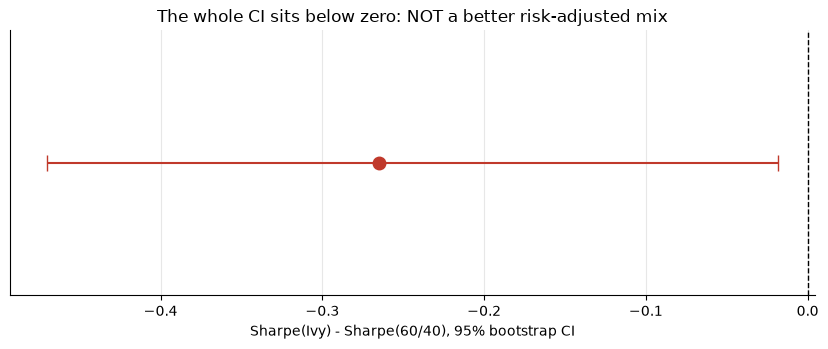

Sharpe diff -0.265  95% CI [-0.470, -0.018]
active return -1.69%/yr  HAC t = -1.12


In [2]:
if HAVE_REAL:
    sw = st.static_weights(RET.index)
    static_net, static_turn = st.weighted_portfolio(RET, sw, cost_bps=5.0)
    b64w = st.sixty_forty_weights(RET.index)
    b64_net, _ = st.weighted_portfolio(RET, b64w, cost_bps=5.0)
    boot = st.bootstrap_sharpe_diff(static_net, b64_net, rf=RF, seed=655)
    a = st.active_stats(static_net, b64_net)
    point, lo, hi = boot['point'], boot['ci95'][0], boot['ci95'][1]
    ann_t = a['ann_pct'], a['hac_t']
else:
    point, lo, hi = R['boot_ivy_64'][0], R['boot_ivy_64'][1], R['boot_ivy_64'][2]
    ann_t = R['act_ivy_64_ann'], R['act_ivy_64_t']
fig, ax = plt.subplots(figsize=(8.4, 3.6))
ax.errorbar([point], [0], xerr=[[point-lo],[hi-point]], fmt='o', color=RED,
    ecolor=RED, capsize=6, markersize=9)
ax.axvline(0, c='k', lw=1, ls='--')
ax.set_yticks([]); ax.set_xlabel('Sharpe(Ivy) - Sharpe(60/40), 95% bootstrap CI')
ax.set_title('The whole CI sits below zero: NOT a better risk-adjusted mix')
plt.tight_layout(); plt.show()
print(f'Sharpe diff {point:+.3f}  95% CI [{lo:+.3f}, {hi:+.3f}]')
print(f'active return {ann_t[0]:+.2f}%/yr  HAC t = {ann_t[1]:+.2f}')

> 💡 In plain words: the point estimate (-0.265) is negative, and the ENTIRE 95% CI (**[-0.470, -0.018]**) stays below zero, stable across 3/6/12-month block sizes. Ivy's Sharpe is **robustly worse** than 60/40's — H₁ is rejected, not merely unproven.

### 4b · Why — two of the five legs were themselves poor investments

Standalone CAGR / Sharpe / max drawdown for each of the five sleeves.

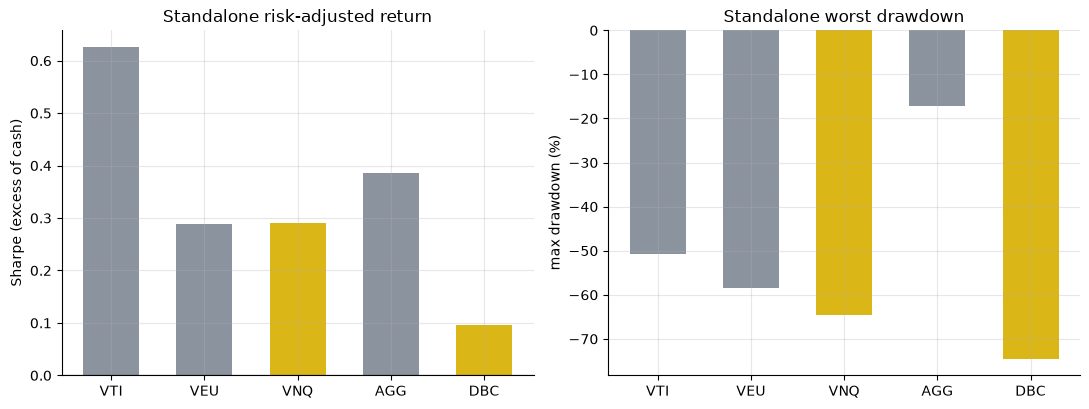

{'VTI': (0.627, -50.8), 'VEU': (0.289, -58.4), 'VNQ': (0.291, -64.6), 'AGG': (0.385, -17.1), 'DBC': (0.096, -74.6)}


In [3]:
if HAVE_REAL:
    rows = {t: st.perf(RET[t], RF) for t in data.ASSETS}
    names = list(rows.keys())
    sh = [rows[n]['sharpe'] for n in names]
    dd = [rows[n]['max_dd']*100 for n in names]
else:
    names = list(R['assets'].keys())
    sh = [R['assets'][n][1] for n in names]
    dd = [R['assets'][n][2] for n in names]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.0, 4.2))
cols = [AMBER if n in ('VNQ', 'DBC') else GREY for n in names]
a1.bar(names, sh, color=cols, width=.6); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('Sharpe (excess of cash)'); a1.set_title('Standalone risk-adjusted return')
a2.bar(names, dd, color=cols, width=.6)
a2.set_ylabel('max drawdown (%)'); a2.set_title('Standalone worst drawdown')
plt.tight_layout(); plt.show()
print({n: (round(s,3), round(d,1)) for n,s,d in zip(names, sh, dd)})

> 💡 In plain words: DBC's Sharpe (**0.10**) is near zero with its own **−75%** drawdown — commodity futures paid a negative roll yield through the 2011-2020 bear market (Bhardwaj, Gorton & Rouwenhorst 2015). VNQ crashed **−65%** in the GFC, correlated *with* equities rather than against them. A blend is only as good as its worst-behaved legs, and two of Faber's five underperformed badly here.

### 4c · H₂ — the 10-month SMA overlay: risk reduction, alpha, or both?

Timed vs static Ivy (same window), and timed vs 60/40.

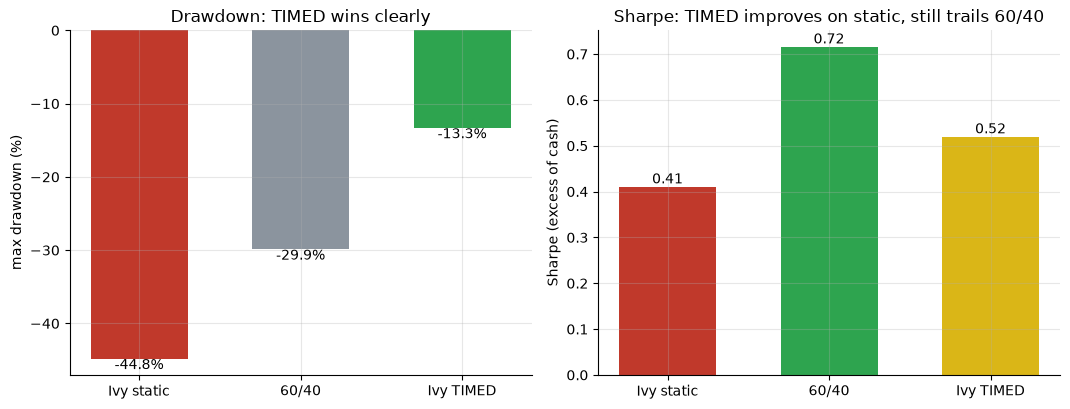

maxDD: {'Ivy static': -44.792399183894425, '60/40': -29.857792059836818, 'Ivy TIMED': -13.284905776082601}
Sharpe: {'Ivy static': 0.41067268273746965, '60/40': 0.7159935123228074, 'Ivy TIMED': 0.5198966821073889}


In [4]:
if HAVE_REAL:
    tw = st.timed_weights(SIG)
    timed_net, timed_turn = st.weighted_portfolio(RET, tw, cost_bps=5.0)
    common = timed_net.index
    ps_c = st.perf(static_net.loc[common], RF)
    pb_c = st.perf(b64_net.loc[common], RF)
    pt = st.perf(timed_net, RF)
    dds = [ps_c['max_dd']*100, pb_c['max_dd']*100, pt['max_dd']*100]
    shs = [ps_c['sharpe'], pb_c['sharpe'], pt['sharpe']]
else:
    dds = [R['ivy_w_dd'], R['b64_w_dd'], R['timed_dd']]
    shs = [R['ivy_w_sharpe'], R['b64_w_sharpe'], R['timed_sharpe']]
labels = ['Ivy static', '60/40', 'Ivy TIMED']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.8, 4.2))
a1.bar(labels, dds, color=[RED, GREY, GREEN], width=.6)
for i, v in enumerate(dds): a1.annotate(f'{v:.1f}%', (i, v), ha='center', va='top')
a1.set_ylabel('max drawdown (%)'); a1.set_title('Drawdown: TIMED wins clearly')
a2.bar(labels, shs, color=[RED, GREEN, AMBER], width=.6)
for i, v in enumerate(shs): a2.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom')
a2.set_ylabel('Sharpe (excess of cash)'); a2.set_title('Sharpe: TIMED improves on static, still trails 60/40')
plt.tight_layout(); plt.show()
print('maxDD:', dict(zip(labels, dds))); print('Sharpe:', dict(zip(labels, shs)))

> 💡 In plain words: drawdown falls from **-45%** (static) to **-13%** (timed) — better than even 60/40's **-30%**. Sharpe improves too (**0.41** → **0.52**) but the bootstrap CI on timed-vs-static Sharpe still spans zero (**[-0.240, +0.414]**, not certified), and timed Ivy's Sharpe never overtakes 60/40's (0.72). Active return vs 60/40 is **-3.84%/yr at HAC t = -2.26** — certified, and negative. Real risk reduction; no alpha.

### 4d · Is the drawdown cut real timing skill, or just less exposure?

Matched-exposure random-timing control: shuffle each sleeve's in/out calendar at random, holding its time-in-market **fixed**. Averaged over 40 seeds (single-seed baselines are banned on this desk).

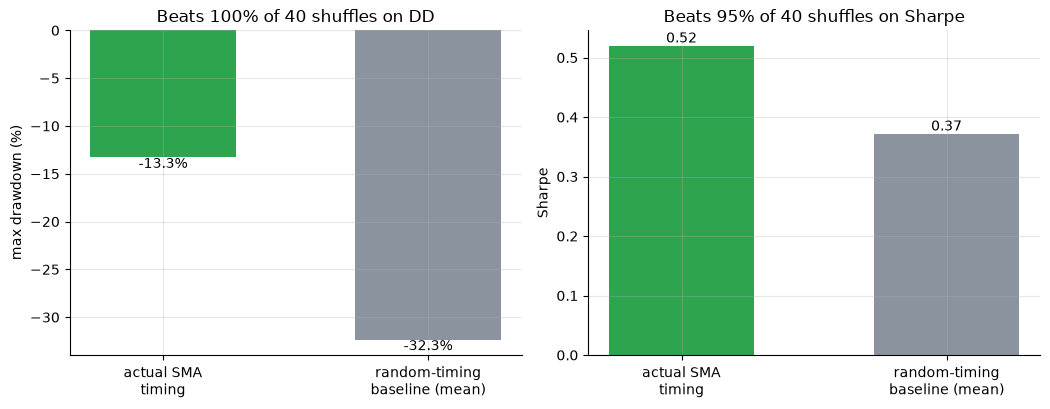

actual dd -13.3% vs baseline -32.3%  (beats 100%)
actual Sh 0.52 vs baseline 0.37  (beats 95%)


In [5]:
if HAVE_REAL:
    rb = st.random_timing_baseline(RET, SIG, cost_bps=5.0, n_seeds=40, base_seed=655)
    actual_sh, actual_dd = rb['actual']['sharpe'], rb['actual']['max_dd']*100
    base_sh, base_dd = rb['base_sharpe_mean'], rb['base_dd_mean']*100
    dd_beat, sh_beat = rb['dd_beat_share']*100, rb['sharpe_beat_share']*100
else:
    actual_sh, actual_dd = R['timed_sharpe'], R['timed_dd']
    base_sh, base_dd = R['rb_base_sharpe'], R['rb_base_dd']
    dd_beat, sh_beat = R['rb_dd_beat'], R['rb_sharpe_beat']
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.6, 4.2))
a1.bar(['actual SMA\ntiming', 'random-timing\nbaseline (mean)'], [actual_dd, base_dd],
       color=[GREEN, GREY], width=.55)
for i, v in enumerate([actual_dd, base_dd]): a1.annotate(f'{v:.1f}%', (i, v), ha='center', va='top')
a1.set_ylabel('max drawdown (%)'); a1.set_title(f'Beats {dd_beat:.0f}% of 40 shuffles on DD')
a2.bar(['actual SMA\ntiming', 'random-timing\nbaseline (mean)'], [actual_sh, base_sh],
       color=[GREEN, GREY], width=.55)
for i, v in enumerate([actual_sh, base_sh]): a2.annotate(f'{v:.2f}', (i, v), ha='center', va='bottom')
a2.set_ylabel('Sharpe'); a2.set_title(f'Beats {sh_beat:.0f}% of 40 shuffles on Sharpe')
plt.tight_layout(); plt.show()
print(f'actual dd {actual_dd:.1f}% vs baseline {base_dd:.1f}%  (beats {dd_beat:.0f}%)')
print(f'actual Sh {actual_sh:.2f} vs baseline {base_sh:.2f}  (beats {sh_beat:.0f}%)')

> 💡 In plain words: a random timer with the SAME average exposure per sleeve gets nowhere close — the actual 10-month rule beats **100%** of 40 random-timing shuffles on drawdown and **95%** on Sharpe. This is genuine, if partial, trend information — not an artefact of spending less time invested.

### 4e · Sub-period — is this all 2008?

Both findings re-run with 2007-07 → 2009-06 (the GFC) dropped entirely.

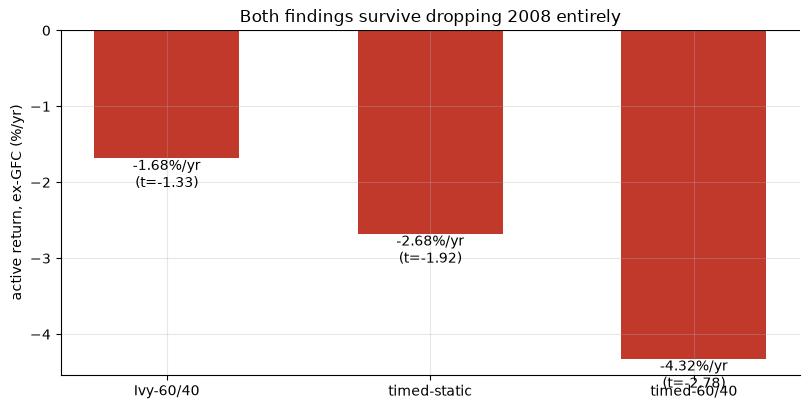

{'Ivy-60/40': (-1.6800197272364463, -1.3279317067175243), 'timed-static': (-2.675699658662609, -1.916712937064284), 'timed-60/40': (-4.320549843969074, -2.777669088737287)}


In [6]:
if HAVE_REAL:
    def ex_gfc(s):
        return s[(s.index < '2007-07-01') | (s.index > '2009-06-30')]
    sg, bg = ex_gfc(static_net), ex_gfc(b64_net)
    a_g = st.active_stats(sg, bg)
    tg = ex_gfc(timed_net)
    sg2 = static_net.loc[tg.index]
    a_ts_g = st.active_stats(tg, sg2)
    a_t64_g = st.active_stats(tg, ex_gfc(b64_net.loc[common]))
    exgfc_vals = [a_g['ann_pct'], a_ts_g['ann_pct'], a_t64_g['ann_pct']]
    exgfc_ts = [a_g['hac_t'], a_ts_g['hac_t'], a_t64_g['hac_t']]
else:
    exgfc_vals = [R['exgfc_act_ivy64'][0], R['exgfc_act_ts'][0], R['exgfc_act_t64'][0]]
    exgfc_ts = [R['exgfc_act_ivy64'][1], R['exgfc_act_ts'][1], R['exgfc_act_t64'][1]]
labels = ['Ivy-60/40', 'timed-static', 'timed-60/40']
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar(labels, exgfc_vals, color=[RED if v<0 else GREEN for v in exgfc_vals], width=.55)
for i, (v, t) in enumerate(zip(exgfc_vals, exgfc_ts)):
    ax.annotate(f'{v:+.2f}%/yr\n(t={t:+.2f})', (i, v), ha='center', va='top' if v<0 else 'bottom')
ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('active return, ex-GFC (%/yr)')
ax.set_title('Both findings survive dropping 2008 entirely')
plt.tight_layout(); plt.show()
print(dict(zip(labels, zip(exgfc_vals, exgfc_ts))))

> 💡 In plain words: ex-GFC, Ivy static still trails 60/40 by **-1.68%/yr** (*t* = -1.33, below the certification bar but consistent) and the timer still trails 60/40 by **-4.32%/yr** (*t* = -2.78, certified) — and its drawdown cut still holds (-19.3% → -13.1%). Neither result is "one great trade in 2008."

### 4f · Costs and turnover

One-way bps x NAV on the total absolute weight change at each monthly rebalance.

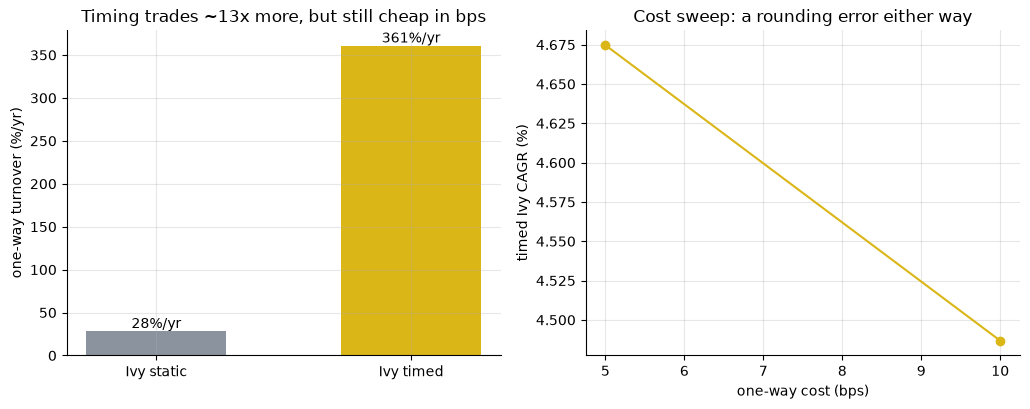

turnover %/yr: 28.140031197386172 360.67776575319976
cost sweep: [(5.0, 4.674727995986516, 0.5198966821073889), (10.0, 4.486764378667396, 0.49368342791970427)]


In [7]:
if HAVE_REAL:
    ann_static = float(static_turn.mean()*12)*100
    ann_timed = float(timed_turn.mean()*12)*100
    rows = []
    for cb in (5.0, 10.0):
        tn, _ = st.weighted_portfolio(RET, tw, cost_bps=cb)
        p = st.perf(tn, RF)
        rows.append((cb, p['cagr']*100, p['sharpe']))
else:
    ann_static, ann_timed = R['turn_static'], R['turn_timed']
    rows = [(5.0, R['timed_cost5'][0], R['timed_cost5'][1]),
            (10.0, R['timed_cost10'][0], R['timed_cost10'][1])]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(10.4, 4.2))
a1.bar(['Ivy static', 'Ivy timed'], [ann_static, ann_timed], color=[GREY, AMBER], width=.55)
for i, v in enumerate([ann_static, ann_timed]): a1.annotate(f'{v:.0f}%/yr', (i, v), ha='center', va='bottom')
a1.set_ylabel('one-way turnover (%/yr)'); a1.set_title('Timing trades ~13x more, but still cheap in bps')
cbs = [r[0] for r in rows]; cagrs = [r[1] for r in rows]
a2.plot(cbs, cagrs, marker='o', color=AMBER)
a2.set_xlabel('one-way cost (bps)'); a2.set_ylabel('timed Ivy CAGR (%)')
a2.set_title('Cost sweep: a rounding error either way')
plt.tight_layout(); plt.show()
print('turnover %/yr:', ann_static, ann_timed)
print('cost sweep:', rows)

> 💡 In plain words: static Ivy trades almost nothing (28%/yr); even the timer's ~9 sleeve-flips/year only cost **~18-36 bps/yr** across the 5/10 bps sweep. Costs are not why this underperforms 60/40 — the legs and the timing trade-off are.

### 4g · Faithful-engine & power control — we know the truth here

A synthetic 5-asset + cash world where a single regime drives all five legs, with a TUNABLE ``persistence`` knob. Unconditional means (persistence=0, a fair 50/50 coin flip) are pinned at realistic positive asset premia **above cash** in every world, so hiding in cash can never mechanically win — only genuine trend information can. Same matched-exposure random-timing test, run inside the synthetic world, averaged over **10 world-seeds x 20 inner shuffle-seeds**.

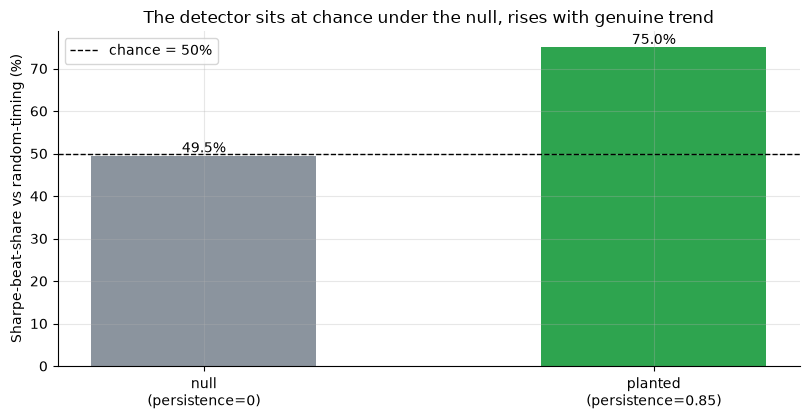

null: Sharpe-beat 49.5%  DD-beat 69.5%
planted: Sharpe-beat 75.0%  DD-beat 82.5%


In [8]:
def synthetic_beat_shares(persistence, n_outer=10, n_inner=20, n_months=300):
    sh, dd = [], []
    for s in range(n_outer):
        panel = data.synthetic_world(persistence=persistence, seed=655+s, n_months=n_months)
        closes = panel[data.ASSETS]
        rets = pd.DataFrame(index=panel.index)
        rets[data.ASSETS] = closes.pct_change()
        rets[data.CASH] = panel[data.CASH+'_lvl'].pct_change()
        rets = rets.dropna(how='all')
        sig_syn = st.sma_signal(closes)
        r = st.random_timing_baseline(rets, sig_syn, cost_bps=5.0, n_seeds=n_inner, base_seed=1000+s)
        sh.append(r['sharpe_beat_share']); dd.append(r['dd_beat_share'])
    return float(np.mean(sh))*100, float(np.mean(dd))*100

null_sh, null_dd = synthetic_beat_shares(0.0)
planted_sh, planted_dd = synthetic_beat_shares(0.85)
fig, ax = plt.subplots(figsize=(8.2, 4.3))
ax.bar(['null\n(persistence=0)', 'planted\n(persistence=0.85)'], [null_sh, planted_sh],
       color=[GREY, GREEN], width=.5)
for i, v in enumerate([null_sh, planted_sh]): ax.annotate(f'{v:.1f}%', (i, v), ha='center', va='bottom')
ax.axhline(50, ls='--', c='k', lw=1, label='chance = 50%')
ax.set_ylabel('Sharpe-beat-share vs random-timing (%)')
ax.set_title('The detector sits at chance under the null, rises with genuine trend')
ax.legend(); plt.tight_layout(); plt.show()
print(f'null: Sharpe-beat {null_sh:.1f}%  DD-beat {null_dd:.1f}%')
print(f'planted: Sharpe-beat {planted_sh:.1f}%  DD-beat {planted_dd:.1f}%')

> 💡 In plain words: under the null the Sharpe-beat-share sits at **49.5%** — chance is 50% — and rises to **75.0%** once a genuine trend is planted. The null's DD-beat-share (**69.5%**, above chance) is a named, honest artefact: a trailing-average rule mechanically tends to have already de-risked after a run of bad returns, capping some downside even with zero informational content — a structural property of trend-following, not skill. The real tape's beat-shares (100% / 95%) exceed even the planted-0.85 world, consistent with one strong sustained trend episode (the GFC) in the sample. *(A faithful-engine / power check only — never cited in support of the real-tape stamp.)*

## 5 · The verdict

- **Signal `MIXED`** — *Real* on the SMA timer's drawdown cut (-45% → -13%, beats 100%/40 matched-exposure shuffles on drawdown, 95%/40 on Sharpe; synthetic detector at chance under the null, rises with planted persistence) · *None* on the static diversification's Sharpe claim (bootstrap 95% CI **[-0.470, -0.018]**, entirely negative, stable across block sizes).
- **Tradability `MIRAGE`** — turnover 28%/yr (static) / 361%/yr (timed), costs ≤36 bps/yr either way — cheap, but neither arm beats a free 60/40 on a risk-adjusted basis (static: robustly worse Sharpe; timed: active -3.84%/yr at HAC t = -2.26 vs 60/40, Sharpe-diff CI still spans zero).
- **"Risk reduction or alpha?" `CONFIRMED` (risk reduction)** — genuine, repeated (ex-GFC) drawdown protection with a genuine, certified return cost. Exactly Faber's own single-asset framing (Study 110), now validated across a 5-asset composite.

## 6 · Going further

- **The general lesson on H₁:** "more asset classes" is not automatically "more diversification" — the marginal legs need to be decent investments on their own. Commodity futures' roll-yield drag (Erb & Harvey 2006; Bhardwaj, Gorton & Rouwenhorst 2015) and REITs' equity-like crash behaviour in systemic crises (2008) are both well-documented, and both bit here.
- **The general lesson on H₂** is Study 110's, now confirmed to generalize: a trailing-average timer is a real, validated crash shield whose cost is a real, certified return drag — not a free lunch, but not nothing either.
- **Natural sequel:** does risk-parity weighting (Study 68's approach) rescue the static allocation by down-weighting DBC and VNQ's outsized volatility instead of equal-weighting blindly? The engine here is ready for that comparison.
- **Dedup map:** [68-all-weather](../../68-all-weather/) (risk parity, different quartet), [110-faber-timing](../../110-faber-timing/) (the same SMA rule, single asset), [144-permanent-portfolio](../../144-permanent-portfolio/) and [203-golden-butterfly](../../203-golden-butterfly/) (equal-weight, no timing, different legs), [592-dual-momentum-gem](../../592-dual-momentum-gem/) (a momentum decision tree, not a diversified blend).

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*